# Fine-Tuning LLMs for Text-to-SQL Generation
## A Fraud Analytics Perspective

### Introduction

Financial fraud detection increasingly relies on rapid, accurate querying of large transactional databases.
Fraud analysts at fintech organisations must translate investigative hypotheses — such as identifying
velocity anomalies, geographic impossibilities, or behavioural deviations — into precise SQL queries.
This process is time-consuming and requires significant technical expertise.

This project explores whether a small language model (Qwen2-0.5B-Instruct) can be fine-tuned to bridge
this gap — converting natural language fraud investigation questions into executable SQL queries. We compare
four training approaches: Full Fine-Tuning, LoRA, QLoRA, and Prefix Tuning, evaluating each across 13
comprehensive metrics.

**Dataset:** Synthetic Text-to-SQL (gretelai/synthetic_text_to_sql) — filtered for financial, insurance,
cybersecurity, and legal domains most relevant to fraud risk management.

**Model:** Qwen2-0.5B-Instruct — a compact, instruction-tuned causal language model chosen for its
efficiency and suitability for parameter-efficient fine-tuning within compute constraints.

In [ ]:
# ============================================================
# SECTION 0 — Setup: installs, GPU check, reproducibility
# ============================================================

# Install all libraries needed for the entire project
!pip install -q transformers datasets peft trl accelerate bitsandbytes sentencepiece
!pip install -q evaluate sacrebleu rouge_score nltk bert_score
!pip install -q detoxify textstat scikit-learn

import torch
import os

# --- GPU check ---
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detected: {gpu_name}")
    print(f"VRAM available: {vram:.1f} GB")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > A100 GPU")

# --- NLTK data for metrics ---
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("NLTK data ready.")

# --- Reproducibility ---
import random
import numpy as np

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed set to {SEED}. Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 116.4 MB/s eta 0:00:00
GPU detected: NVIDIA A100-SXM4-40GB
VRAM available: 42.4 GB
NLTK data ready.
Seed set to 42. Setup complete.


## Section 0 — Environment Setup

All dependencies are installed upfront to ensure reproducibility. Training is conducted on an NVIDIA A100
(40GB VRAM) via Google Colab Pro. A fixed random seed of 42 is used across all methods for fair comparison.
Both the dataset (gretelai/synthetic_text_to_sql) and model (Qwen/Qwen2-0.5B-Instruct) are publicly available and require no authentication.

In [ ]:
# ============================================================
# SECTION 0 — Part 2: Shared Config (A100 optimised)
# ============================================================

import os

# --- Save directory ---
SAVE_DIR = "/content/SQL_FT_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoints will be saved to: {SAVE_DIR}")

# --- Model ---
MODEL_ID   = "Qwen/Qwen2-0.5B-Instruct"
MAX_LENGTH = 512

# --- Shared training config ---
SEED          = 42
EPOCHS        = 1
BATCH_SIZE    = 8           # upgraded from 4 — A100 has 42GB
GRAD_ACCUM    = 2           # effective batch = 16
LEARNING_RATE = 2e-4
WARMUP_STEPS  = 50

# --- Full epoch for all methods on A100 ---
# 10,003 train examples / batch size 8 = ~1,250 steps per epoch
FULL_FT_MAX_STEPS = -1     # full epoch
PEFT_MAX_STEPS    = -1     # full epoch

print("Config ready.")
print(f"Effective batch size:  {BATCH_SIZE * GRAD_ACCUM}")
print(f"Full FT max steps:     Full epoch")
print(f"PEFT max steps:        Full epoch")
print(f"Model:                 {MODEL_ID}")
print(f"Save directory:        {SAVE_DIR}")

Checkpoints will be saved to: /content/SQL_FT_checkpoints
Config ready.
Effective batch size:  16
Full FT max steps:     Full epoch
PEFT max steps:        Full epoch
Model:                 Qwen/Qwen2-0.5B-Instruct
Save directory:        /content/SQL_FT_checkpoints


## Section 1 — Dataset Preparation

### Dataset Selection Rationale

The Synthetic Text-to-SQL dataset (Gretel AI) contains 100,000 training and 5,851 test examples spanning
100 domains. For this project, we filter for domains directly relevant to fraud risk management:

- **Finance & Financial Services** — transaction analysis, portfolio risk, customer profiling
- **Insurance** — claims investigation, risk scoring, policy compliance
- **Cybersecurity** — anomaly detection, access pattern analysis
- **Legal Services & Justice** — case investigation, compliance reporting
- **Blockchain** — transaction tracing, smart contract analysis

This domain filtering ensures the model learns SQL patterns most applicable to financial crime investigation,
such as aggregations over transaction tables, threshold-based filtering, temporal joins, and velocity checks.

### Prompt Template Design

Each training example is formatted as an instruction-following prompt with three components:
1. A fraud-analyst framing in the system instruction
2. The database schema (CREATE TABLE statements)
3. The natural language question

The model must generate the corresponding SQL query.

In [ ]:
# ============================================================
# SECTION 1 — Dataset Preparation
# ============================================================

# Force reinstall pyarrow and datasets to resolve potential binary incompatibility
#!pip install --upgrade --force-reinstall pyarrow datasets

from datasets import load_dataset
import pandas as pd

# --- Load Synthetic Text-to-SQL dataset ---
print("Loading dataset...")
raw_dataset = load_dataset("gretelai/synthetic_text_to_sql")
print(raw_dataset)

# --- Inspect columns ---
print("\nColumn names:", raw_dataset["train"].column_names)
print("\nFirst example:")
for k, v in raw_dataset["train"][0].items():
    print(f"  {k}: {str(v)[:200]}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…):   0%|          | 0.00/32.4M [00:00<?, ?B/s]

synthetic_text_to_sql_test.snappy.parque(…):   0%|          | 0.00/1.90M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})

Column names: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']

First example:
  id: 5097
  domain: forestry
  domain_description: Comprehensive data on sustainable forest management, timber production, wildlife habitat, and carbon sequestration in forestry.
  sql_complexity: single join
  sql_complexity_description: only on

In [ ]:
# --- See all unique domains ---
print("All unique domains:")
print(sorted(raw_dataset["train"].to_pandas()["domain"].unique().tolist()))
print(f"\nTotal unique domains: {raw_dataset['train'].to_pandas()['domain'].nunique()}")

All unique domains:
['aerospace', 'agriculture', 'aquaculture', 'archeology', 'arctic research', 'artificial intelligence', 'arts and culture', 'arts operations and management', 'automotive', 'beauty industry', 'biotechnology', 'blockchain', 'cannabis industry', 'charitable organizations', 'chemicals', 'civil engineering', 'climate change', 'construction', 'cosmetics', 'cultural preservation', 'cybersecurity', 'defense contractors', 'defense industry', 'defense operations', 'defense security', 'disability services', 'education', 'energy', 'entertainment industry', 'ethical fashion', 'fashion', 'fashion retail', 'finance', 'financial services', 'fine arts', 'fitness industry', 'food industry', 'food services', 'forestry', 'gaming industry', 'gaming technology', 'government policy', 'government services', 'healthcare', 'higher education', 'hospitality', 'hospitality technology', 'human resources', 'humanitarian aid', 'insurance', 'journalism', 'justice', 'legal services', 'logistics', 'm

In [ ]:
# ============================================================
# SECTION 1 — Part 3: Filter for Fraud-Relevant Domains & Format
# ============================================================

# --- Filter for fraud/risk relevant domains ---
FRAUD_RELEVANT_DOMAINS = [
    "finance",
    "financial services",
    "insurance",
    "cybersecurity",
    "public safety",
    "legal services",
    "justice",
    "blockchain",
    "venture capital",
    "social impact investing"
]

train_df = raw_dataset["train"].to_pandas()
test_df  = raw_dataset["test"].to_pandas()

train_filtered = train_df[train_df["domain"].isin(FRAUD_RELEVANT_DOMAINS)]
test_filtered  = test_df[test_df["domain"].isin(FRAUD_RELEVANT_DOMAINS)]

print(f"Original train size:  {len(train_df)}")
print(f"Filtered train size:  {len(train_filtered)}")
print(f"Original test size:   {len(test_df)}")
print(f"Filtered test size:   {len(test_filtered)}")
print(f"\nDomain distribution in filtered train:")
print(train_filtered["domain"].value_counts())

# --- Prompt template ---
# Framed as a fraud analyst assistant:
# Given a database schema + natural language question → generate SQL
def format_prompt(sql_context, sql_prompt, sql=""):
    prompt = f"""You are an expert SQL assistant helping fraud analysts investigate financial crimes.
Given the database schema and a natural language question, write the correct SQL query.

### Database Schema:
{sql_context}

### Question:
{sql_prompt}

### SQL Query:
{sql}"""
    return prompt

# --- Apply formatting ---
def preprocess(df):
    texts = []
    for _, row in df.iterrows():
        text = format_prompt(
            row["sql_context"],
            row["sql_prompt"],
            row["sql"]
        )
        texts.append(text)
    return texts

train_texts = preprocess(train_filtered)
test_texts  = preprocess(test_filtered)

print(f"\nFormatted train examples: {len(train_texts)}")
print(f"Formatted test examples:  {len(test_texts)}")
print("\n--- Sample formatted prompt ---")
print(train_texts[0][:800])

Original train size:  100000
Filtered train size:  10003
Original test size:   5851
Filtered test size:   580

Domain distribution in filtered train:
domain
cybersecurity              1360
financial services         1134
public safety              1131
finance                    1051
blockchain                 1051
justice                     980
insurance                   940
legal services              916
social impact investing     732
venture capital             708
Name: count, dtype: int64

Formatted train examples: 10003
Formatted test examples:  580

--- Sample formatted prompt ---
You are an expert SQL assistant helping fraud analysts investigate financial crimes.
Given the database schema and a natural language question, write the correct SQL query.

### Database Schema:
CREATE TABLE trade_history (id INT, trader_id INT, stock VARCHAR(255), price DECIMAL(5,2), quantity INT, trade_time TIMESTAMP);

### Question:
What is the total trade value and average price for each trader

In [ ]:
# --- Convert to HuggingFace datasets format ---
from datasets import Dataset

# Keep raw test data for evaluation (we need sql_prompt, sql_context, sql separately)
test_raw = test_filtered.reset_index(drop=True)

# For training we only need the formatted text
from datasets import Dataset

train_dataset = Dataset.from_dict({"text": train_texts})

# For test we keep both formatted and raw
test_dataset  = Dataset.from_dict({
    "text":        test_texts,
    "sql_prompt":  test_filtered["sql_prompt"].tolist(),
    "sql_context": test_filtered["sql_context"].tolist(),
    "sql":         test_filtered["sql"].tolist(),        # reference SQL for evaluation
    "domain":      test_filtered["domain"].tolist(),
})

# --- Evaluation subset ---
# We have 580 test examples — use all of them (exceeds our 500 target)
EVAL_SAMPLES = min(500, len(test_dataset))
test_eval = test_dataset.select(range(EVAL_SAMPLES))

print(f"Train dataset:      {len(train_dataset)} examples")
print(f"Test dataset:       {len(test_dataset)} examples")
print(f"Evaluation subset:  {EVAL_SAMPLES} examples")
print("\nTrain sample:")
print(train_dataset["text"][0][:400])

Train dataset:      10003 examples
Test dataset:       580 examples
Evaluation subset:  500 examples

Train sample:
You are an expert SQL assistant helping fraud analysts investigate financial crimes.
Given the database schema and a natural language question, write the correct SQL query.

### Database Schema:
CREATE TABLE trade_history (id INT, trader_id INT, stock VARCHAR(255), price DECIMAL(5,2), quantity INT, trade_time TIMESTAMP);

### Question:
What is the total trade value and average price for each trade


In [ ]:
# ============================================================
# SECTION 2 — Load Base Model and Tokenizer (Qwen2-0.5B-Instruct)
# ============================================================

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# --- Load tokenizer ---
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokenizer loaded.")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Pad token:  {tokenizer.pad_token}")
print(f"EOS token:  {tokenizer.eos_token}")

# --- Load base model in 4-bit for sanity check ---
print("\nLoading base model for sanity check...")
bnb_config_check = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_check = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config_check,
    device_map="auto"
)
model_check.config.use_cache = False
print(f"Model parameters: {model_check.num_parameters()/1e6:.1f}M")

# --- Sanity check: base model before any fine-tuning ---
print("\n--- Base model output (before fine-tuning) ---")

sample_context = test_eval["sql_context"][0]
sample_prompt  = test_eval["sql_prompt"][0]
sample_ref     = test_eval["sql"][0]

sanity_input = format_prompt(sample_context, sample_prompt)
inputs = tokenizer(
    sanity_input,
    return_tensors="pt",
    truncation=True,
    max_length=400
).to("cuda")

with torch.no_grad():
    output = model_check.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output[0], skip_special_tokens=True)
response  = generated.split("### SQL Query:")[-1].strip()

print(f"Question:        {sample_prompt}")
print(f"Base model SQL:  {response[:300]}")
print(f"Reference SQL:   {sample_ref[:300]}")

# --- Base model response saved for reference (not used in Section 6b qualitative
# comparison, which loads from results_df generated in Section 4) ---
base_model_sample = {
    "question":  sample_prompt,
    "context":   sample_context,
    "base":      response,
    "reference": sample_ref
}

# --- Free VRAM ---
del model_check
torch.cuda.empty_cache()
print("\nBase model removed. VRAM cleared. Ready for fine-tuning.")

Loading tokenizer...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model parameters: 494.0M

--- Base model output (before fine-tuning) ---
Question:        Add a new attorney named 'Oliver Martinez' with email 'oliver.martinez@lawfirm.com' and phone '555-555-5678' to the 'attorneys' table
Base model SQL:  INSERT INTO attorneys VALUES (?, ?, ?) SELECT * FROM attorneys WHERE attorney_name = 'Oliver Martinez' AND attorney_email = 'oliver.martinez@lawfirm.com' AND attorney_phone = '555-555-5678';
Reference SQL:   INSERT INTO attorneys (attorney_name, attorney_email, attorney_phone) VALUES ('Oliver Martinez', 'oliver.martinez@lawfirm.com', '555-555-5678');

Base model removed. VRAM cleared. Ready for fine-tuning.


## Section 3 — Model Fine-Tuning
1. Full Fine-Tuning  
   - All model parameters updated

2. LoRA  
   - Low-rank adapters added to attention layers

3. QLoRA  
   - Quantized model + LoRA adapters

4. Prefix Tuning  
   - Trainable prefix vectors added to input sequence

## Section 3 — Model Fine-Tuning

We train four variants of Qwen2-0.5B-Instruct using identical hyperparameters where possible,
to ensure a fair comparison:

| Hyperparameter | Value |
|---|---|
| Learning Rate | 2e-4 |
| Effective Batch Size | 16 |
| Epochs | 1 |
| Warmup Steps | 50 |
| Max Sequence Length | 512 |
| Optimiser | AdamW |
| LR Scheduler | Linear |

### Method 1 — Full Fine-Tuning

Full fine-tuning updates all 494 million parameters of the base model. This is the most
computationally expensive approach but serves as our performance ceiling. We use fp32
precision to ensure gradient stability — mixed precision (fp16) causes gradient scaling
errors when all parameters are being updated simultaneously. Gradient checkpointing is
enabled to manage VRAM usage.

**Trainable parameters:** 494M (100%)

In [ ]:
# ============================================================
# SECTION 3 — Method 1: Full Fine-Tuning (A100 optimised)
# ============================================================

from transformers import AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig
import torch

print("Loading fresh base model for Full Fine-Tuning...")

model_full = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float32       # fp32 required for stable full FT
)
model_full.config.use_cache = False

print(f"Trainable parameters: {model_full.num_parameters()/1e6:.1f}M")

sft_config_full = SFTConfig(
    output_dir=f"{SAVE_DIR}/full_ft",
    num_train_epochs=EPOCHS,
    max_steps=FULL_FT_MAX_STEPS,
    per_device_train_batch_size=4,      # 4 (not BATCH_SIZE=8) — fp32 needs extra VRAM headroom; effective batch = 16 preserved via grad_accum=4
    gradient_accumulation_steps=4,      # effective batch = 16
    learning_rate=LEARNING_RATE,
    fp16=False,                         # disabled — causes FP16 gradient error
    bf16=False,                         # A100 supports bf16 but unstable with full FT
    logging_steps=50,
    save_strategy="no",
    eval_strategy="no",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=WARMUP_STEPS,
    seed=SEED,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
    gradient_checkpointing=True,
)

trainer_full = SFTTrainer(
    model=model_full,
    train_dataset=train_dataset,
    args=sft_config_full,
    processing_class=tokenizer,
)

print("\nStarting Full Fine-Tuning...")
print("Running full epoch (~1,250 steps, ~30-35 mins on A100)\n")

trainer_full.train()

full_ft_loss_log = [(x['step'], x['loss']) for x in trainer_full.state.log_history if 'loss' in x]
pd.DataFrame(full_ft_loss_log, columns=["step","loss"]).to_csv(f"{SAVE_DIR}/full_ft_losses.csv", index=False)

# --- Save ---
full_ft_path = f"{SAVE_DIR}/full_ft/final"
model_full.save_pretrained(full_ft_path)
tokenizer.save_pretrained(full_ft_path)
print(f"\nFull FT model saved to: {full_ft_path}")

# --- Free VRAM ---
del model_full, trainer_full
torch.cuda.empty_cache()
print("VRAM cleared. Ready for Method 2.")


Loading fresh base model for Full Fine-Tuning...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Trainable parameters: 494.0M


Adding EOS to train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



Starting Full Fine-Tuning...
Running full epoch (~1,250 steps, ~30-35 mins on A100)



Step,Training Loss
50,0.683531
100,0.688296
150,0.661725
200,0.591711
250,0.570664
300,0.538688
350,0.509032
400,0.477073
450,0.455671
500,0.426718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Full FT model saved to: /content/SQL_FT_checkpoints/full_ft/final
VRAM cleared. Ready for Method 2.


### Method 2 — LoRA (Low-Rank Adaptation)

LoRA injects trainable low-rank decomposition matrices into the attention and MLP layers,
freezing the original weights. With rank r=16 and alpha=32, LoRA adds approximately 8.8M
trainable parameters — just 1.75% of the full model.

The key insight is that model adaptations during fine-tuning have a low intrinsic rank.
Rather than updating the full weight matrix W, LoRA learns two smaller matrices A and B
such that the update ΔW = BA, where the rank of BA is at most r=16.

**Trainable parameters:** 8.8M (1.75%)  
**Target modules:** q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj

In [ ]:
# ============================================================
# SECTION 3 — Method 2: LoRA (Low-Rank Adaptation)
# ============================================================

from transformers import AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, get_peft_model, TaskType
import torch

print("Loading fresh base model for LoRA...")

model_lora = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16)
model_lora.config.use_cache = False

# --- LoRA config ---
# r=16: rank — controls capacity of the adaptation
# lora_alpha=32: scaling factor (alpha/r = 2 is a good default)
# target_modules: which layers to adapt — all attention + MLP for best coverage
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj",
        "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()

sft_config_lora = SFTConfig(
    output_dir=f"{SAVE_DIR}/lora",
    num_train_epochs=EPOCHS,
    max_steps=PEFT_MAX_STEPS,           # full epoch
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    fp16=True,                          # safe with float16 + LoRA
    bf16=False,
    logging_steps=100,
    save_strategy="no",
    eval_strategy="no",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=WARMUP_STEPS,
    seed=SEED,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
)

trainer_lora = SFTTrainer(
    model=model_lora,
    train_dataset=train_dataset,
    args=sft_config_lora,
    processing_class=tokenizer,
)

print("\nStarting LoRA Fine-Tuning...")
print(f"Running {PEFT_MAX_STEPS} steps (~8-10 mins on A100)\n")

trainer_lora.train()

lora_loss_log = [(x['step'], x['loss']) for x in trainer_lora.state.log_history if 'loss' in x]
pd.DataFrame(lora_loss_log, columns=["step","loss"]).to_csv(f"{SAVE_DIR}/lora_losses.csv", index=False)

# --- Save ---
lora_path = f"{SAVE_DIR}/lora/final"
model_lora.save_pretrained(lora_path)
tokenizer.save_pretrained(lora_path)
print(f"\nLoRA model saved to: {lora_path}")

# --- Free VRAM ---
del model_lora, trainer_lora
torch.cuda.empty_cache()
print("VRAM cleared. Ready for Method 3.")

Loading fresh base model for LoRA...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


Adding EOS to train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



Starting LoRA Fine-Tuning...
Running -1 steps (~8-10 mins on A100)



Step,Training Loss
100,0.632434
200,0.453230
300,0.430361
400,0.414651
500,0.399251
600,0.399546



LoRA model saved to: /content/SQL_FT_checkpoints/lora/final
VRAM cleared. Ready for Method 3.


### Method 3 — QLoRA (Quantized LoRA)

QLoRA combines 4-bit quantization of the base model with LoRA adapters, dramatically
reducing memory requirements. The base model weights are stored in NormalFloat4 (nf4)
format with double quantization, while the LoRA adapters remain in bfloat16 for stable
gradient computation.

This approach enables fine-tuning of models that would otherwise not fit in GPU memory,
making it particularly valuable for deployment in resource-constrained environments —
relevant for fintech organisations running inference on-premise.

**Trainable parameters:** 8.8M (1.75%) — same as LoRA  
**Base model precision:** 4-bit NF4  
**Compute dtype:** bfloat16

In [ ]:
# ============================================================
# SECTION 3 — Method 3: QLoRA (Quantized LoRA)
# ============================================================

from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import torch

print("Loading fresh base model for QLoRA (4-bit quantized)...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model_qlora = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto")

model_qlora = prepare_model_for_kbit_training(model_qlora)
model_qlora.config.use_cache = False

# --- Same LoRA config as Method 2 for fair comparison ---
lora_config_q = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj",
        "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model_qlora = get_peft_model(model_qlora, lora_config_q)
model_qlora.print_trainable_parameters()

sft_config_qlora = SFTConfig(
    output_dir=f"{SAVE_DIR}/qlora",
    num_train_epochs=EPOCHS,
    max_steps=PEFT_MAX_STEPS,           # full epoch
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    fp16=False,
    bf16=True,                          # bfloat16 required for 4-bit training
    logging_steps=100,
    save_strategy="no",
    eval_strategy="no",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=WARMUP_STEPS,
    seed=SEED,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
)

trainer_qlora = SFTTrainer(
    model=model_qlora,
    train_dataset=train_dataset,
    args=sft_config_qlora,
    processing_class=tokenizer,
)

print("\nStarting QLoRA Fine-Tuning...")
print(f"Running {PEFT_MAX_STEPS} steps (~8-10 mins on A100)\n")

trainer_qlora.train()

qlora_loss_log = [(x['step'], x['loss']) for x in trainer_qlora.state.log_history if 'loss' in x]
pd.DataFrame(qlora_loss_log, columns=["step","loss"]).to_csv(f"{SAVE_DIR}/qlora_losses.csv", index=False)


# --- Save ---
qlora_path = f"{SAVE_DIR}/qlora/final"
model_qlora.save_pretrained(qlora_path)
tokenizer.save_pretrained(qlora_path)
print(f"\nQLoRA model saved to: {qlora_path}")

# --- Free VRAM ---
del model_qlora, trainer_qlora
torch.cuda.empty_cache()
print("VRAM cleared. Ready for Method 4.")

Loading fresh base model for QLoRA (4-bit quantized)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


Adding EOS to train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



Starting QLoRA Fine-Tuning...
Running -1 steps (~8-10 mins on A100)



Step,Training Loss
100,0.656580
200,0.461249
300,0.436955
400,0.420804
500,0.405798
600,0.406330



QLoRA model saved to: /content/SQL_FT_checkpoints/qlora/final
VRAM cleared. Ready for Method 4.


### Method 4 — Prefix Tuning

Prefix Tuning prepends a small set of learnable "virtual tokens" to the input sequence,
steering the frozen model's behaviour without modifying any weights. With 10 virtual tokens,
only 61,440 parameters are trained — 0.012% of the model.

This approach is fundamentally different from LoRA — rather than adapting the model's
internal representations, it learns a task-specific prompt in the embedding space.
While extremely parameter-efficient, its capacity is severely limited for tasks requiring
precise structured output like SQL generation.

**Trainable parameters:** 61K (0.012%)  
**Virtual tokens:** 10  
**Prefix projection:** Disabled (incompatible with Qwen2 architecture)

In [ ]:
# ============================================================
# SECTION 3 — Method 4: Prefix Tuning
# ============================================================

from transformers import AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig
from peft import PrefixTuningConfig, get_peft_model, TaskType
import torch

print("Loading fresh base model for Prefix Tuning...")

model_prefix = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16)
model_prefix.config.use_cache      = False
model_prefix.config.pretraining_tp = 1

# --- Prefix Tuning config ---
# num_virtual_tokens: number of trainable prefix tokens prepended to input
# prefix_projection disabled — causes tensor mismatch with Qwen2
prefix_config = PrefixTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    num_virtual_tokens=10,
    prefix_projection=False,
)

model_prefix = get_peft_model(model_prefix, prefix_config)
model_prefix.print_trainable_parameters()

sft_config_prefix = SFTConfig(
    output_dir=f"{SAVE_DIR}/prefix",
    num_train_epochs=EPOCHS,
    max_steps=PEFT_MAX_STEPS,           # full epoch
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    fp16=True,
    bf16=False,
    logging_steps=100,
    save_strategy="no",
    eval_strategy="no",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=WARMUP_STEPS,
    seed=SEED,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
    gradient_checkpointing=False,       # incompatible with prefix tuning
)

trainer_prefix = SFTTrainer(
    model=model_prefix,
    train_dataset=train_dataset,
    args=sft_config_prefix,
    processing_class=tokenizer,
)

print("\nStarting Prefix Tuning...")
print(f"Running {PEFT_MAX_STEPS} steps (~12-15 mins on A100)\n")

trainer_prefix.train()

prefix_loss_log = [(x['step'], x['loss']) for x in trainer_prefix.state.log_history if 'loss' in x]
pd.DataFrame(prefix_loss_log, columns=["step","loss"]).to_csv(f"{SAVE_DIR}/prefix_losses.csv", index=False)

# --- Save ---
prefix_path = f"{SAVE_DIR}/prefix/final"
model_prefix.save_pretrained(prefix_path)
tokenizer.save_pretrained(prefix_path)
print(f"\nPrefix Tuning model saved to: {prefix_path}")

# --- Free VRAM ---
del model_prefix, trainer_prefix
torch.cuda.empty_cache()
print("All 4 methods complete. Ready for Section 4 — Text Generation.")

Loading fresh base model for Prefix Tuning...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 61,440 || all params: 494,094,208 || trainable%: 0.0124


Adding EOS to train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



Starting Prefix Tuning...
Running -1 steps (~12-15 mins on A100)



Step,Training Loss
100,6.747624
200,5.068891
300,4.286798
400,3.870570
500,3.629600
600,3.560146



Prefix Tuning model saved to: /content/SQL_FT_checkpoints/prefix/final
All 4 methods complete. Ready for Section 4 — Text Generation.


## Section 4 — Text Generation

We generate SQL responses for 500 test examples per method using greedy decoding
(do_sample=False) for deterministic, reproducible outputs. Each model receives the
same formatted prompt — database schema + natural language question — and must generate
the corresponding SQL query.

A maximum of 150 new tokens is allowed per response, sufficient for most SQL queries
in this dataset. The generated text is extracted by splitting on the "### SQL Query:"
delimiter in the prompt template.

In [ ]:
# ============================================================
# SECTION 4 — Text Generation (all 4 methods)
# ============================================================

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import torch
import pandas as pd

TEST_SAMPLES = 500
test_subset  = test_eval

print(f"Generating SQL responses for {TEST_SAMPLES} test examples per method...")

# --- Helper: generate SQL from prompt ---
def generate_sql(model, tokenizer, sql_context, sql_prompt, max_new_tokens=150):
    prompt = format_prompt(sql_context, sql_prompt)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400,
    ).to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    if "### SQL Query:" in generated:
        response = generated.split("### SQL Query:")[-1].strip()
    else:
        response = generated[len(prompt):].strip()
    return response

# --- Store all results ---
results = {
    "sql_prompt":  list(test_subset["sql_prompt"]),
    "sql_context": list(test_subset["sql_context"]),
    "reference":   list(test_subset["sql"]),
    "domain":      list(test_subset["domain"]),
}

# ============================================================
# Method 1: Full Fine-Tuning
# ============================================================
print("\n[1/4] Loading Full FT model...")
model_ft = AutoModelForCausalLM.from_pretrained(
    f"{SAVE_DIR}/full_ft/final",
    device_map="auto",
    torch_dtype=torch.float16,
)
tokenizer_ft = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/full_ft/final")
tokenizer_ft.pad_token = tokenizer_ft.eos_token

print("Generating Full FT responses...")
full_ft_responses = []
for i in range(TEST_SAMPLES):
    resp = generate_sql(
        model_ft, tokenizer_ft,
        test_subset["sql_context"][i],
        test_subset["sql_prompt"][i]
    )
    full_ft_responses.append(resp)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{TEST_SAMPLES} done")

results["full_ft"] = full_ft_responses
del model_ft, tokenizer_ft
torch.cuda.empty_cache()
print("Full FT done.")

# ============================================================
# Method 2: LoRA
# ============================================================
print("\n[2/4] Loading LoRA model...")
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16)
model_lora = PeftModel.from_pretrained(base, f"{SAVE_DIR}/lora/final")
tokenizer_lora = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/lora/final")
tokenizer_lora.pad_token = tokenizer_lora.eos_token

print("Generating LoRA responses...")
lora_responses = []
for i in range(TEST_SAMPLES):
    resp = generate_sql(
        model_lora, tokenizer_lora,
        test_subset["sql_context"][i],
        test_subset["sql_prompt"][i]
    )
    lora_responses.append(resp)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{TEST_SAMPLES} done")

results["lora"] = lora_responses
del model_lora, base, tokenizer_lora
torch.cuda.empty_cache()
print("LoRA done.")

# ============================================================
# Method 3: QLoRA
# ============================================================
print("\n[3/4] Loading QLoRA model...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
base_q = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto")
model_qlora = PeftModel.from_pretrained(base_q, f"{SAVE_DIR}/qlora/final")
tokenizer_qlora = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/qlora/final")
tokenizer_qlora.pad_token = tokenizer_qlora.eos_token

print("Generating QLoRA responses...")
qlora_responses = []
for i in range(TEST_SAMPLES):
    resp = generate_sql(
        model_qlora, tokenizer_qlora,
        test_subset["sql_context"][i],
        test_subset["sql_prompt"][i]
    )
    qlora_responses.append(resp)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{TEST_SAMPLES} done")

results["qlora"] = qlora_responses
del model_qlora, base_q, tokenizer_qlora
torch.cuda.empty_cache()
print("QLoRA done.")

# ============================================================
# Method 4: Prefix Tuning
# ============================================================
print("\n[4/4] Loading Prefix Tuning model...")
base_p = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16
)
model_prefix = PeftModel.from_pretrained(base_p, f"{SAVE_DIR}/prefix/final")
tokenizer_prefix = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/prefix/final")
tokenizer_prefix.pad_token = tokenizer_prefix.eos_token

print("Generating Prefix Tuning responses...")
prefix_responses = []
for i in range(TEST_SAMPLES):
    resp = generate_sql(
        model_prefix, tokenizer_prefix,
        test_subset["sql_context"][i],
        test_subset["sql_prompt"][i]
    )
    prefix_responses.append(resp)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{TEST_SAMPLES} done")

results["prefix_tuning"] = prefix_responses
del model_prefix, base_p, tokenizer_prefix
torch.cuda.empty_cache()
print("Prefix Tuning done.")

# ============================================================
# Save all results
# ============================================================
results_df = pd.DataFrame(results)
results_path = f"{SAVE_DIR}/generated_responses.csv"
results_df.to_csv(results_path, index=False)

print(f"\nAll responses saved to: {results_path}")
print(f"Shape: {results_df.shape}")
print("\n--- Sample output ---")
print(f"Question:  {results_df['sql_prompt'][0]}")
print(f"Reference: {results_df['reference'][0]}")
print(f"Full FT:   {results_df['full_ft'][0]}")
print(f"LoRA:      {results_df['lora'][0]}")
print(f"QLoRA:     {results_df['qlora'][0]}")
print(f"Prefix:    {results_df['prefix_tuning'][0]}")

Generating SQL responses for 500 test examples per method...

[1/4] Loading Full FT model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Generating Full FT responses...
  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
Full FT done.

[2/4] Loading LoRA model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Generating LoRA responses...
  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
LoRA done.

[3/4] Loading QLoRA model...


...

Generating QLoRA responses...
  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
QLoRA done.

[4/4] Loading Prefix Tuning model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Generating Prefix Tuning responses...


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2141: UserWarning: Position ids are not supported for parameter efficient tuning. Ignoring position ids.
  warnings.warn("Position ids are not supported for parameter efficient tuning. Ignoring position ids.")


  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
Prefix Tuning done.

All responses saved to: /content/SQL_FT_checkpoints/generated_responses.csv
Shape: (500, 8)

--- Sample output ---
Question:  Add a new attorney named 'Oliver Martinez' with email 'oliver.martinez@lawfirm.com' and phone '555-555-5678' to the 'attorneys' table
Reference: INSERT INTO attorneys (attorney_name, attorney_email, attorney_phone) VALUES ('Oliver Martinez', 'oliver.martinez@lawfirm.com', '555-555-5678');
Full FT:   INSERT INTO attorneys (attorney_id, attorney_name, attorney_phone, attorney_phone) VALUES (1, 'Olivia Martinez', 'olivia.martinez@example.com', '555-555-5678');
LoRA:      INSERT INTO attorneys (attorney_id, attorney_name, attorney_email, attorney_phone) VALUES (3, 'Oliver Martinez', 'oliver.martinez@lawfirm.com', '555-555-5678');
QLoRA:     INSERT INTO attorneys (attorney_id, attorney_name, attorney_email, attorney_phone) VALUES (1, 'Oliver Martinez', 'oliver.martinez@law

## Section 5 — Evaluation

We evaluate generated SQL across 13 metrics covering four dimensions:

**Similarity to reference SQL:**
- **BLEU** — n-gram precision against reference (standard MT metric)
- **ROUGE-1/2/L** — recall-oriented overlap at unigram, bigram, and longest common subsequence level
- **METEOR** — alignment-based metric accounting for synonyms and stemming
- **GLEU** — sentence-level BLEU variant
- **CoSIM** — semantic cosine similarity using sentence embeddings (all-MiniLM-L6-v2)
- **BERT Score** — contextual embedding similarity using RoBERTa-large

**Output quality:**
- **Repetition Rate** — proportion of repeated tokens (lower = better)
- **Flesch Reading Ease** — readability score (higher = more readable prose; for SQL, lower expected)
- **Toxicity** — detoxify model toxicity score (lower = better)

**Diversity & novelty:**
- **Novelty** — semantic distance between generated SQL and input question
- **Diversity** — average pairwise semantic distance across generated outputs

In [ ]:
# ============================================================
# SECTION 5 — Evaluation (13 metrics)
# ============================================================

SEED = 42
import nltk
import numpy as np
import pandas as pd
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.translate.gleu_score import corpus_gleu
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from detoxify import Detoxify
import textstat
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch

# --- Load results ---
results_df = pd.read_csv(f"{SAVE_DIR}/generated_responses.csv")
print(f"Loaded results: {results_df.shape}")

methods    = ["full_ft", "lora", "qlora", "prefix_tuning"]
references = results_df["reference"].tolist()
inputs     = results_df["sql_prompt"].tolist()

# ============================================================
# Metric helper functions
# ============================================================

# --- BLEU ---
def compute_bleu(hypotheses, references):
    ref_tokenized = [[r.split()] for r in references]
    hyp_tokenized = [h.split() for h in hypotheses]
    smoothie = SmoothingFunction().method4
    return corpus_bleu(ref_tokenized, hyp_tokenized, smoothing_function=smoothie)

# --- ROUGE ---
def compute_rouge(hypotheses, references):
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"], use_stemmer=True
    )
    r1, r2, rl = [], [], []
    for h, r in zip(hypotheses, references):
        scores = scorer.score(r, h)
        r1.append(scores["rouge1"].fmeasure)
        r2.append(scores["rouge2"].fmeasure)
        rl.append(scores["rougeL"].fmeasure)
    return np.mean(r1), np.mean(r2), np.mean(rl)

# --- METEOR ---
def compute_meteor(hypotheses, references):
    scores = []
    for h, r in zip(hypotheses, references):
        score = meteor_score([r.split()], h.split())
        scores.append(score)
    return np.mean(scores)

# --- GLEU ---
def compute_gleu(hypotheses, references):
    ref_tokenized = [[r.split()] for r in references]
    hyp_tokenized = [h.split() for h in hypotheses]
    return corpus_gleu(ref_tokenized, hyp_tokenized)

# --- Repetition Rate ---
def compute_repetition_rate(hypotheses):
    rates = []
    for h in hypotheses:
        words = h.split()
        if len(words) == 0:
            rates.append(0)
            continue
        unique = len(set(words))
        rate   = 1 - (unique / len(words))
        rates.append(rate)
    return np.mean(rates)

# --- Flesch Reading Ease ---
def compute_flesch(hypotheses):
    scores = []
    for h in hypotheses:
        if len(h.strip()) == 0:
            scores.append(0)
            continue
        scores.append(textstat.flesch_reading_ease(h))
    return np.mean(scores)

# --- CoSIM (cosine similarity using sentence embeddings) ---
print("Loading sentence encoder for CoSIM...")
cosim_tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)
cosim_model = AutoModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
).to("cuda")

def mean_pooling(model_output, attention_mask):
    token_embeddings    = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(
        token_embeddings.size()
    ).float()
    return torch.sum(
        token_embeddings * input_mask_expanded, 1
    ) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

def get_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch   = texts[i:i+batch_size]
        encoded = cosim_tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors="pt"
        ).to("cuda")
        with torch.no_grad():
            output = cosim_model(**encoded)
        embeddings = mean_pooling(output, encoded["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

def compute_cosim(hypotheses, references):
    hyp_emb = get_embeddings(hypotheses)
    ref_emb = get_embeddings(references)
    scores  = [
        cosine_similarity([h], [r])[0][0]
        for h, r in zip(hyp_emb, ref_emb)
    ]
    return np.mean(scores)

# --- BERT Score ---
def compute_bert_score(hypotheses, references):
    P, R, F1 = bert_score(
        hypotheses, references, lang="en", verbose=False
    )
    return F1.mean().item()

# --- Toxicity ---
print("Loading toxicity model...")
toxicity_model = Detoxify("original")

def compute_toxicity(hypotheses):
    scores = []
    for h in hypotheses:
        if len(h.strip()) == 0:
            scores.append(1.0)
            continue
        result = toxicity_model.predict(h)
        scores.append(result["toxicity"])
    return np.mean(scores)

# --- Novelty (how different generated SQL is from input question) ---
def compute_novelty(hypotheses, inputs):
    hyp_emb = get_embeddings(hypotheses)
    inp_emb = get_embeddings(inputs)
    novelty_scores = [
        1 - cosine_similarity([h], [i])[0][0]
        for h, i in zip(hyp_emb, inp_emb)
    ]
    return np.mean(novelty_scores)

# --- Diversity (how different responses are from each other) ---
def compute_diversity(hypotheses):
    embeddings = get_embeddings(hypotheses)
    scores     = []
    np.random.seed(SEED)
    indices = np.random.choice(
        len(hypotheses), size=400, replace=False
    ).reshape(200, 2)
    for i, j in indices:
        if i != j:
            sim = cosine_similarity(
                [embeddings[i]], [embeddings[j]]
            )[0][0]
            scores.append(1 - sim)
    return np.mean(scores)

# ============================================================
# Run all metrics for each method
# ============================================================

all_scores = {}

for method in methods:
    print(f"\nEvaluating: {method}...")
    hypotheses = results_df[method].fillna("").tolist()

    bleu            = compute_bleu(hypotheses, references)
    r1, r2, rl      = compute_rouge(hypotheses, references)
    meteor          = compute_meteor(hypotheses, references)
    gleu            = compute_gleu(hypotheses, references)
    repetition      = compute_repetition_rate(hypotheses)
    flesch          = compute_flesch(hypotheses)
    cosim           = compute_cosim(hypotheses, references)
    bert            = compute_bert_score(hypotheses, references)
    toxicity        = compute_toxicity(hypotheses)
    novelty         = compute_novelty(hypotheses, inputs)
    diversity       = compute_diversity(hypotheses)

    all_scores[method] = {
        "BLEU":                round(bleu, 4),
        "ROUGE-1":             round(r1, 4),
        "ROUGE-2":             round(r2, 4),
        "ROUGE-L":             round(rl, 4),
        "METEOR":              round(meteor, 4),
        "GLEU":                round(gleu, 4),
        "Repetition Rate":     round(repetition, 4),
        "Flesch Reading Ease": round(flesch, 2),
        "CoSIM":               round(cosim, 4),
        "BERT Score":          round(bert, 4),
        "Toxicity":            round(toxicity, 4),
        "Novelty":             round(novelty, 4),
        "Diversity":           round(diversity, 4),
    }
    print(f"  Done: BLEU={bleu:.4f}, ROUGE-1={r1:.4f}, BERT={bert:.4f}")

# ============================================================
# Display & save results
# ============================================================

scores_df = pd.DataFrame(all_scores).T
scores_df.index.name = "Method"
scores_df.index      = ["Full FT", "LoRA", "QLoRA", "Prefix Tuning"]

print("\n" + "="*70)
print("FINAL EVALUATION RESULTS")
print("="*70)
print(scores_df.to_string())

scores_path = f"{SAVE_DIR}/evaluation_scores.csv"
scores_df.to_csv(scores_path, index_label="Method")
print(f"\nScores saved to: {scores_path}")

Loaded results: (500, 8)
Loading sentence encoder for CoSIM...


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done: BLEU=0.4501, ROUGE-1=0.8032, BERT=0.9538

Evaluating: prefix_tuning...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done: BLEU=0.0005, ROUGE-1=0.0883, BERT=0.7623

FINAL EVALUATION RESULTS
                 BLEU  ROUGE-1  ROUGE-2  ROUGE-L  METEOR    GLEU  Repetition Rate  Flesch Reading Ease   CoSIM  BERT Score  Toxicity  Novelty  Diversity
Full FT        0.4759   0.8121   0.6890   0.7833  0.7035  0.4676           0.0535                17.64  0.9323      0.9565    0.0007   0.3961     0.6717
LoRA           0.4533   0.8129   0.6780   0.7789  0.6972  0.4515           0.0540                16.28  0.9317      0.9555    0.0007   0.3908     0.6740
QLoRA          0.4501   0.8032   0.6687   0.7684  0.6847  0.4407           0.0553                17.89  0.9287      0.9538    0.0007   0.3909     0.6758
Prefix Tuning  0.0005   0.0883   0.0119   0.0764  0.0329  0.0043           0.4844                61.06  0.3029      0.7623    0.0022   0.7556     0.7605

Scores saved to: /content/SQL_FT_checkpoints/evaluation_scores.csv


## Section 6 — Results & Analysis

### Quantitative Results

The table below presents all 13 metrics across the four fine-tuning methods.
Key observations are discussed in the analysis section following the visualisations.

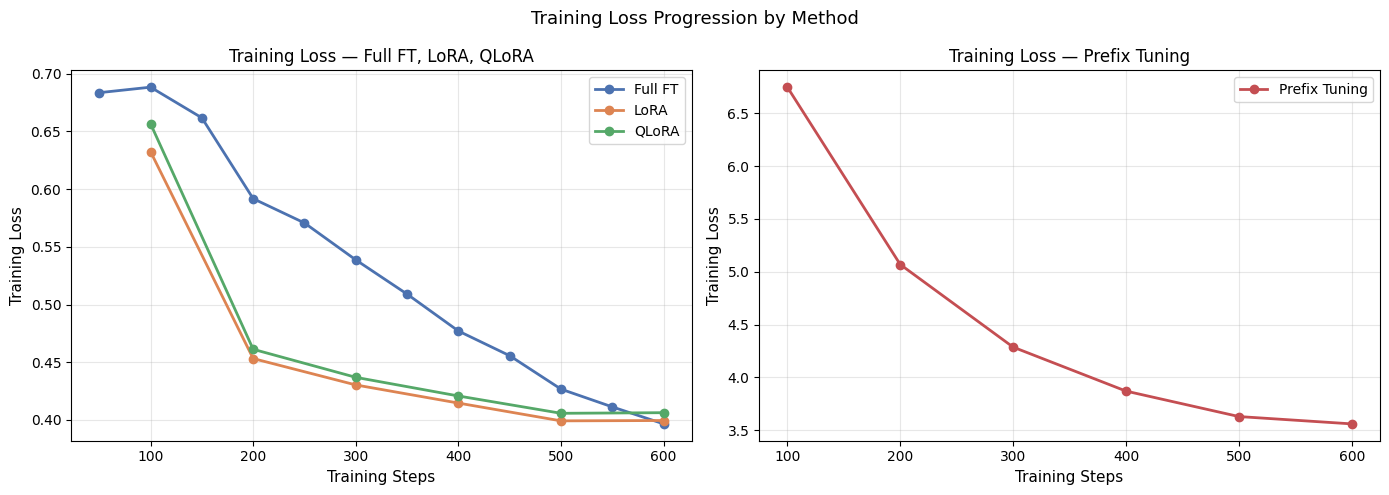

Saved: training_loss.png


In [ ]:
# ============================================================
# SECTION 6.a — Training Loss Progression (dynamic from logs)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load from saved CSVs in case session was interrupted
full_ft_loss_log = pd.read_csv(f"{SAVE_DIR}/full_ft_losses.csv").values.tolist()
lora_loss_log    = pd.read_csv(f"{SAVE_DIR}/lora_losses.csv").values.tolist()
qlora_loss_log   = pd.read_csv(f"{SAVE_DIR}/qlora_losses.csv").values.tolist()
prefix_loss_log  = pd.read_csv(f"{SAVE_DIR}/prefix_losses.csv").values.tolist()

# Build combined dataframe
loss_records = []
for step, loss in full_ft_loss_log:
    loss_records.append({"method": "Full FT",       "step": step, "loss": loss})
for step, loss in lora_loss_log:
    loss_records.append({"method": "LoRA",          "step": step, "loss": loss})
for step, loss in qlora_loss_log:
    loss_records.append({"method": "QLoRA",         "step": step, "loss": loss})
for step, loss in prefix_loss_log:
    loss_records.append({"method": "Prefix Tuning", "step": step, "loss": loss})

loss_df = pd.DataFrame(loss_records)

colors = {
    "Full FT":       "#4C72B0",
    "LoRA":          "#DD8452",
    "QLoRA":         "#55A868",
    "Prefix Tuning": "#C44E52",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — Full FT, LoRA, QLoRA (similar loss scale)
for method in ["Full FT", "LoRA", "QLoRA"]:
    subset = loss_df[loss_df["method"] == method]
    ax1.plot(subset["step"], subset["loss"],
             marker="o", label=method,
             color=colors[method], linewidth=2)

ax1.set_xlabel("Training Steps", fontsize=11)
ax1.set_ylabel("Training Loss", fontsize=11)
ax1.set_title("Training Loss — Full FT, LoRA, QLoRA", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Right — Prefix Tuning (very different scale)
subset = loss_df[loss_df["method"] == "Prefix Tuning"]
ax2.plot(subset["step"], subset["loss"],
         marker="o", color=colors["Prefix Tuning"],
         linewidth=2, label="Prefix Tuning")
ax2.set_xlabel("Training Steps", fontsize=11)
ax2.set_ylabel("Training Loss", fontsize=11)
ax2.set_title("Training Loss — Prefix Tuning", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle("Training Loss Progression by Method", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_loss.png", dpi=150)
plt.show()
print("Saved: training_loss.png")

EVALUATION RESULTS TABLE
                 BLEU  ROUGE-1  ROUGE-2  ROUGE-L  METEOR    GLEU  Repetition Rate  Flesch Reading Ease   CoSIM  BERT Score  Toxicity  Novelty  Diversity
Method                                                                                                                                                  
Full FT        0.4759   0.8121   0.6890   0.7833  0.7035  0.4676           0.0535                17.64  0.9323      0.9565    0.0007   0.3961     0.6717
LoRA           0.4533   0.8129   0.6780   0.7789  0.6972  0.4515           0.0540                16.28  0.9317      0.9555    0.0007   0.3908     0.6740
QLoRA          0.4501   0.8032   0.6687   0.7684  0.6847  0.4407           0.0553                17.89  0.9287      0.9538    0.0007   0.3909     0.6758
Prefix Tuning  0.0005   0.0883   0.0119   0.0764  0.0329  0.0043           0.4844                61.06  0.3029      0.7623    0.0022   0.7556     0.7605


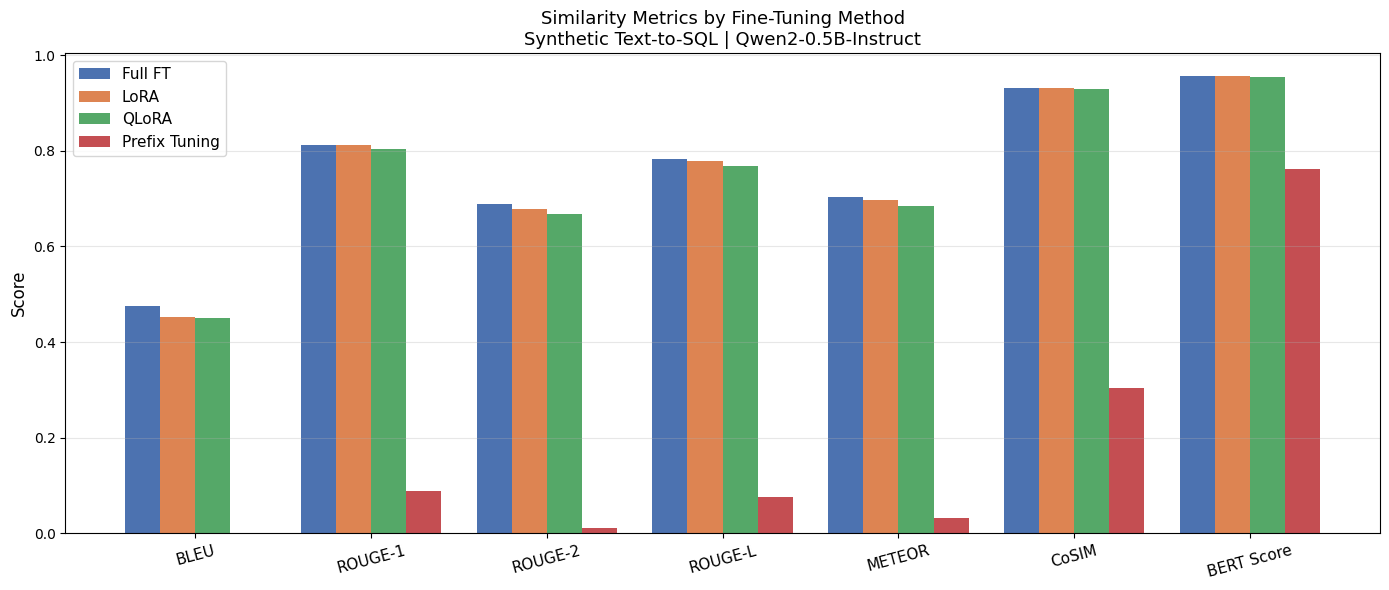

Saved: similarity_metrics.png


In [ ]:
# ============================================================
# SECTION 6.b — Evaluation Results Table + Similarity Metrics
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

scores_df = pd.read_csv(f"{SAVE_DIR}/evaluation_scores.csv", index_col="Method")

print("="*70)
print("EVALUATION RESULTS TABLE")
print("="*70)
print(scores_df.to_string())

# --- Similarity metrics chart ---
similarity_metrics = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L",
    "METEOR", "CoSIM", "BERT Score"
]
sim_df  = scores_df[similarity_metrics]
methods = sim_df.index.tolist()
x       = np.arange(len(similarity_metrics))
width   = 0.2
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, method in enumerate(methods):
    ax.bar(
        x + i*width,
        sim_df.loc[method].values,
        width,
        label=method,
        color=colors[i]
    )

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(similarity_metrics, rotation=15, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Similarity Metrics by Fine-Tuning Method\n"
    "Synthetic Text-to-SQL | Qwen2-0.5B-Instruct",
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/similarity_metrics.png", dpi=150)
plt.show()
print("Saved: similarity_metrics.png")

/tmp/ipykernel_3644/1970015228.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


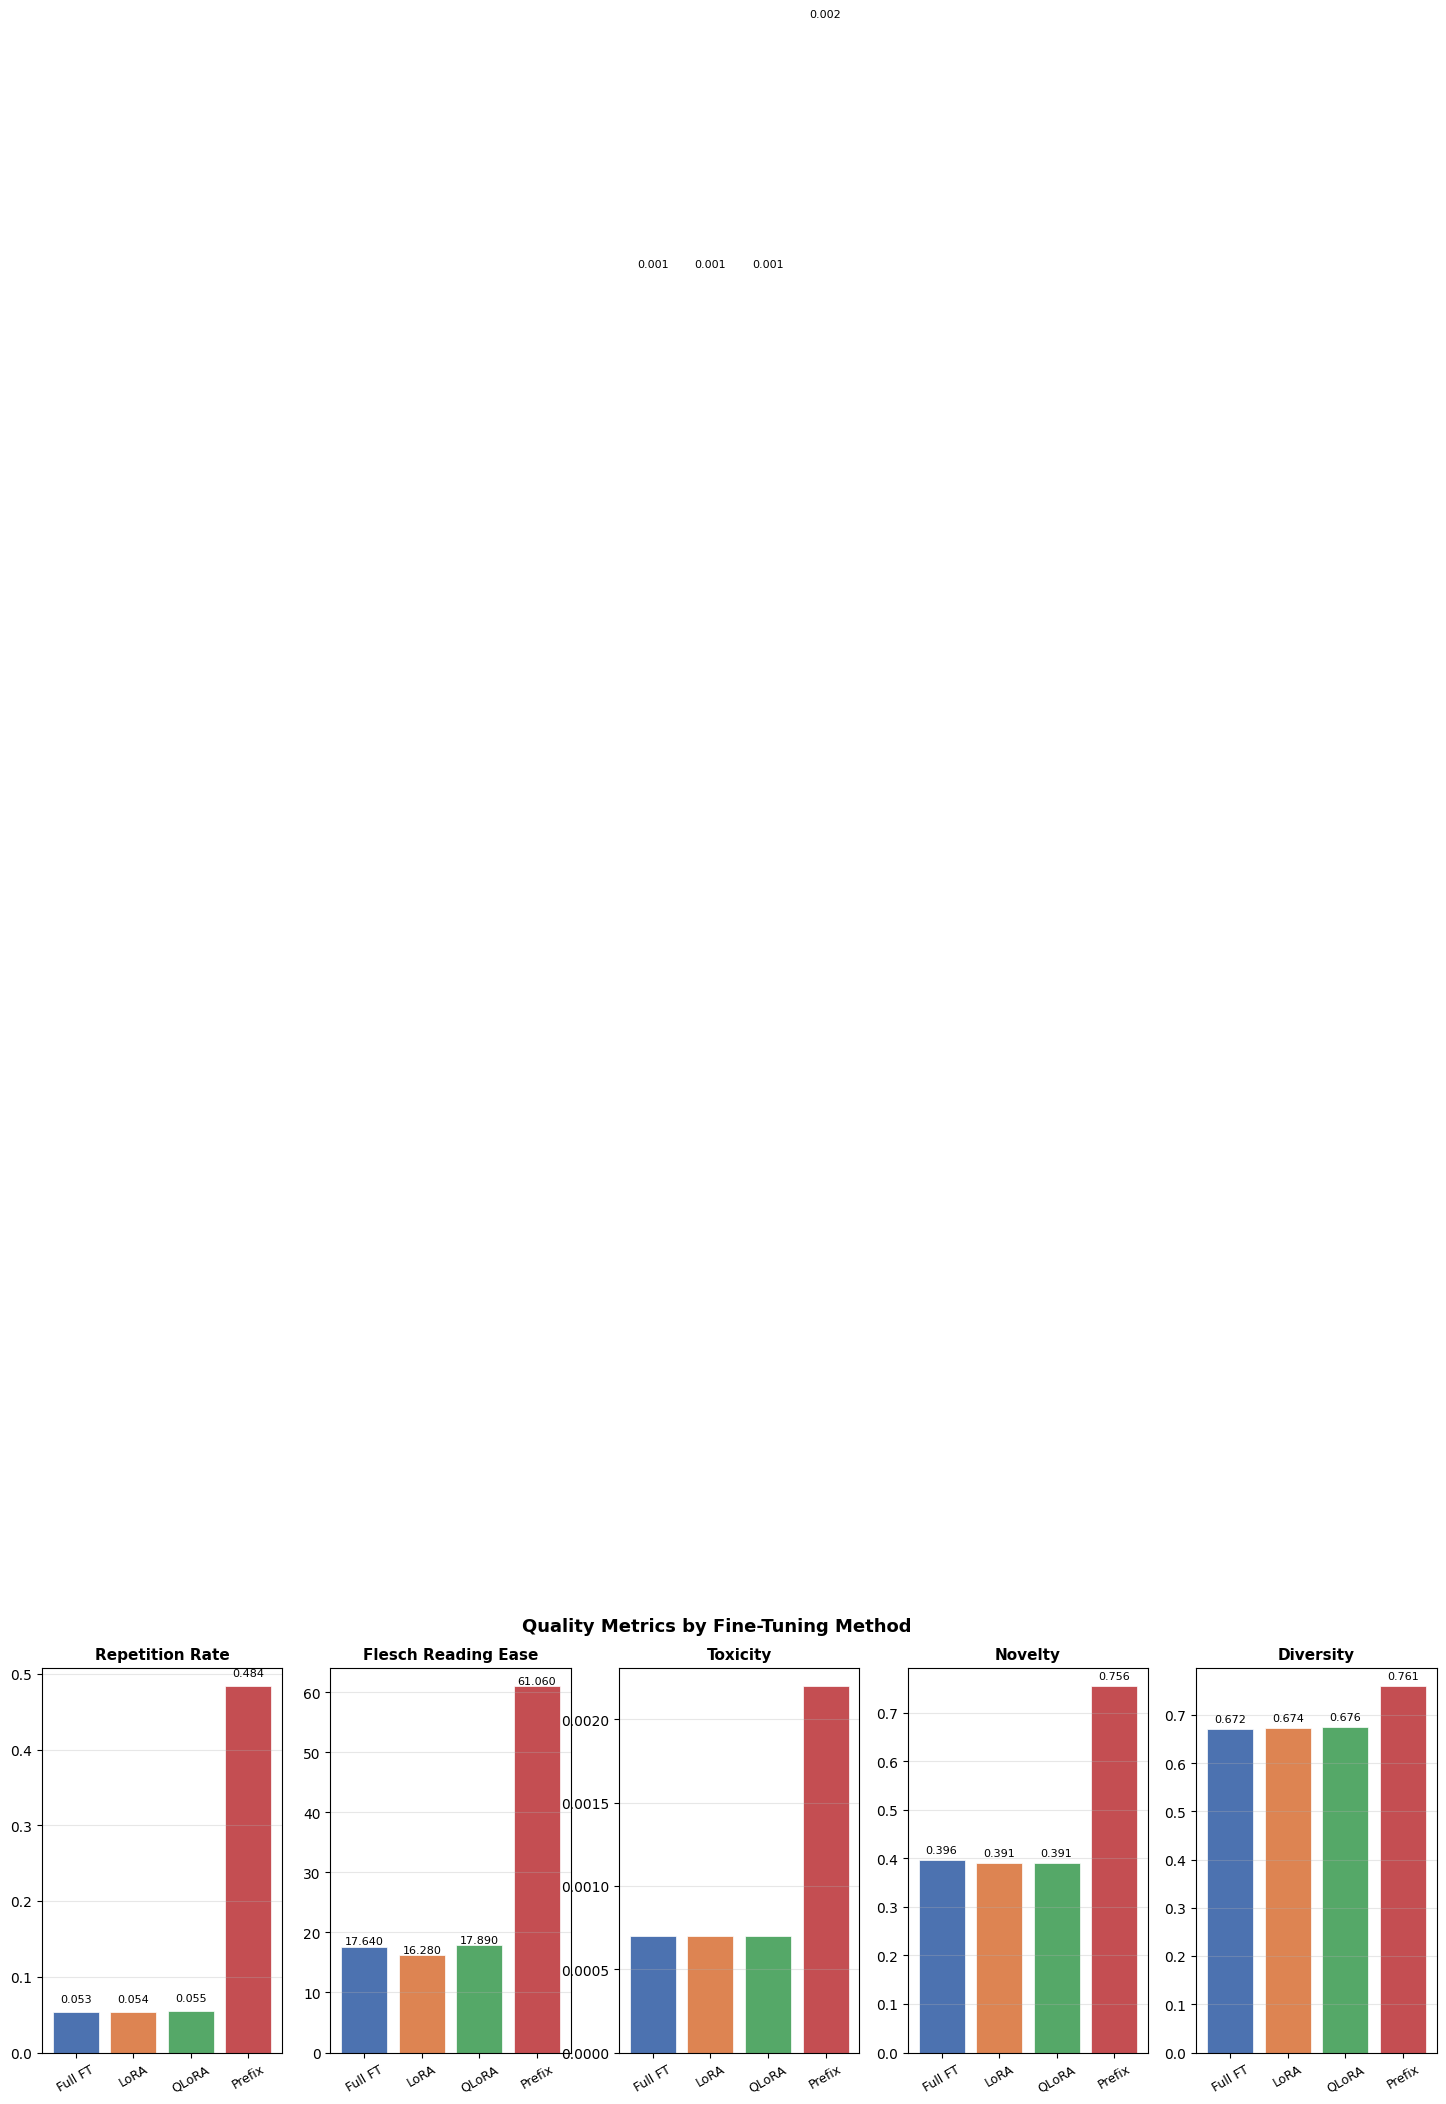

Saved: other_metrics.png

SUMMARY
Best BERT Score:       Full FT
Best ROUGE-1:          LoRA
Best BLEU:             Full FT
Lowest Toxicity:       Full FT
Highest Diversity:     Prefix Tuning
Lowest Repetition:     Full FT
Best Flesch Ease:      Prefix Tuning


In [ ]:
# ============================================================
# SECTION 6.c — Quality Metrics + Summary
# ============================================================

other_metrics = [
    "Repetition Rate", "Flesch Reading Ease",
    "Toxicity", "Novelty", "Diversity"
]
other_df = scores_df[other_metrics]
methods  = scores_df.index.tolist()
colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for idx, metric in enumerate(other_metrics):
    bars = axes[idx].bar(
        methods,
        other_df[metric].values,
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )
    axes[idx].set_title(metric, fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(len(methods)))
    axes[idx].set_xticklabels(
        ["Full FT", "LoRA", "QLoRA", "Prefix"],
        rotation=30, fontsize=9
    )
    axes[idx].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, other_df[metric].values):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Quality Metrics by Fine-Tuning Method",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/other_metrics.png", dpi=150)
plt.show()
print("Saved: other_metrics.png")

# --- Summary ---
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Best BERT Score:       {scores_df['BERT Score'].idxmax()}")
print(f"Best ROUGE-1:          {scores_df['ROUGE-1'].idxmax()}")
print(f"Best BLEU:             {scores_df['BLEU'].idxmax()}")
print(f"Lowest Toxicity:       {scores_df['Toxicity'].idxmin()}")
print(f"Highest Diversity:     {scores_df['Diversity'].idxmax()}")
print(f"Lowest Repetition:     {scores_df['Repetition Rate'].idxmin()}")
print(f"Best Flesch Ease:      {scores_df['Flesch Reading Ease'].idxmax()}")

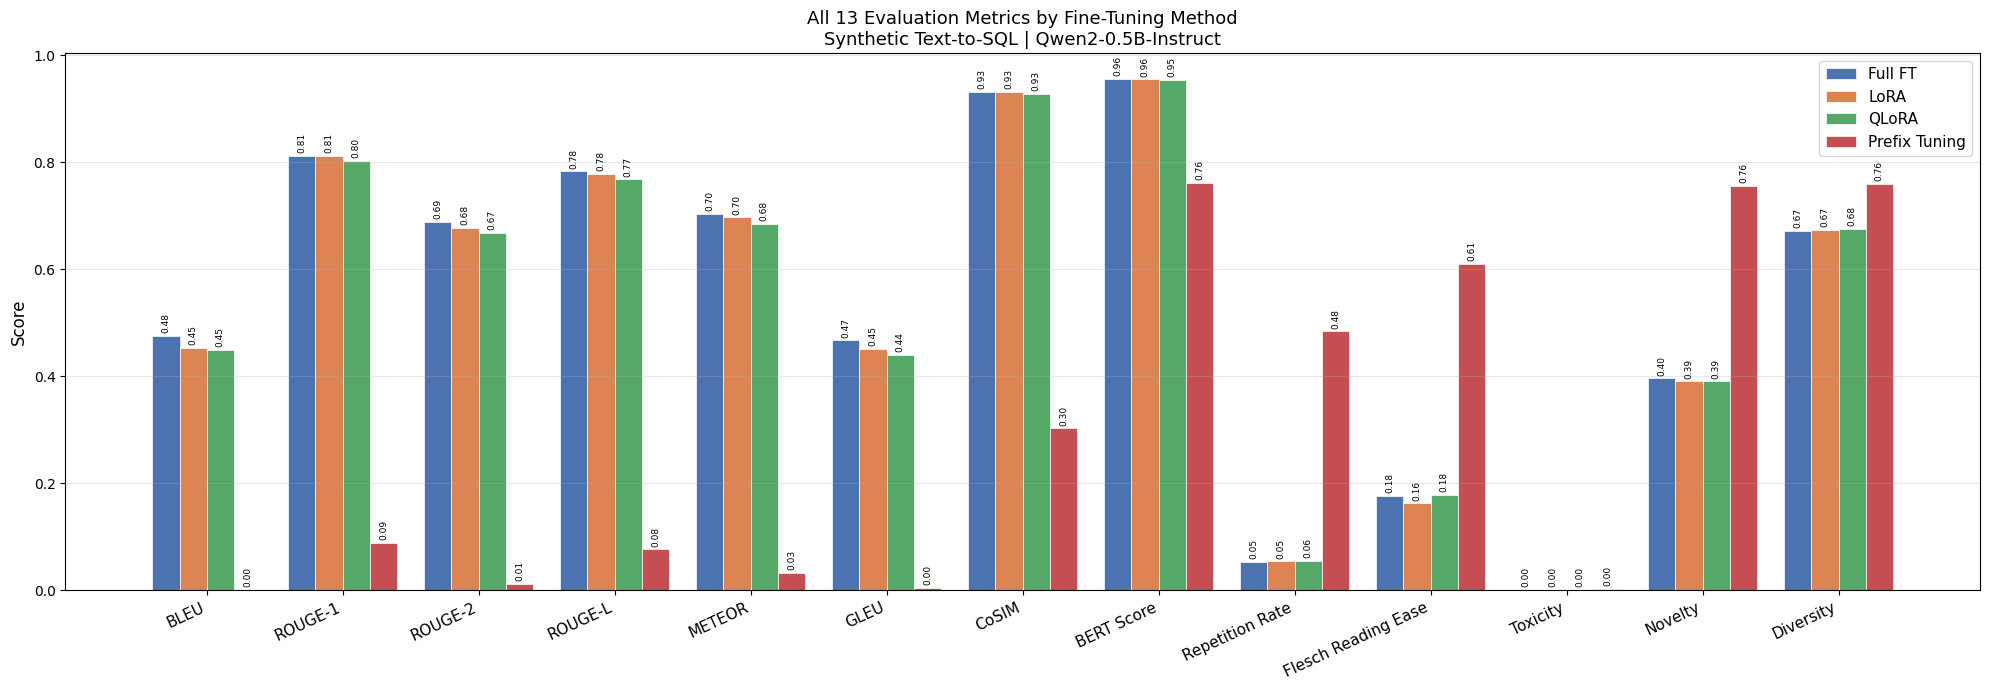

Saved: all_metrics.png


In [ ]:
# ============================================================
# Combined Metrics Bar Chart — all 13 metrics in one figure
# ============================================================

all_metrics = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L",
    "METEOR", "GLEU", "CoSIM", "BERT Score",
    "Repetition Rate", "Flesch Reading Ease",
    "Toxicity", "Novelty", "Diversity"
]

all_df  = scores_df[all_metrics]
methods = all_df.index.tolist()
x       = np.arange(len(all_metrics))
width   = 0.2
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# Normalise Flesch to 0-1 scale for visual comparison only
all_df = all_df.copy()
all_df["Flesch Reading Ease"] = all_df["Flesch Reading Ease"] / 100

fig, ax = plt.subplots(figsize=(20, 7))
for i, method in enumerate(methods):
    ax.bar(
        x + i*width,
        all_df.loc[method].values,
        width,
        label=method,
        color=colors[i],
        edgecolor="white",
        linewidth=0.5
    )

# Value labels on each bar
for i, method in enumerate(methods):
    for j, val in enumerate(all_df.loc[method].values):
        ax.text(
            x[j] + i*width,
            val + 0.005,
            f"{val:.2f}",
            ha="center", va="bottom",
            fontsize=6.5, rotation=90
        )

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(all_metrics, rotation=25, ha="right", fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "All 13 Evaluation Metrics by Fine-Tuning Method\n"
    "Synthetic Text-to-SQL | Qwen2-0.5B-Instruct",
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/all_metrics.png", dpi=150)
plt.show()
print("Saved: all_metrics.png")

## Section 6d — Qualitative Output Inspection

To complement the quantitative metrics, we inspect actual model outputs side by side for a sample of test questions. This reveals *how* the methods differ in practice — particularly the contrast between LoRA (near-identical to Full FT) and Prefix Tuning (which generates natural language prose rather than SQL).

Rather than selecting examples arbitrarily, we use a data-driven approach
to identify the most illustrative contrasts. We filter for rows where LoRA
produced a substantive response (output length > 50 characters) but Prefix
Tuning clearly failed (output length < 30 characters). This surfaces cases
where the performance gap between methods is most visible.

The candidate indices are then inspected manually to select three examples
that span different domains and query types.

In [ ]:
# ============================================================
# SECTION 6.b — Qualitative Examples (Side-by-side SQL comparison)
# ============================================================

import pandas as pd

# Find rows where prefix tuning clearly fails but others succeed
results_df['lora_len'] = results_df['lora'].str.len()
results_df['prefix_len'] = results_df['prefix_tuning'].str.len()

# Rows where LoRA is long (generated something) but prefix is short (failed)
contrast_rows = results_df[
    (results_df['lora_len'] > 50) &
    (results_df['prefix_len'] < 30)
].index.tolist()

print(contrast_rows[:10])  # look at first 10 candidates

[108, 123, 126, 203, 252, 254, 381, 397, 437]


In [ ]:
for idx in [108, 123, 126, 203, 252, 254, 381, 397, 437]:
    row = results_df.iloc[idx]
    print(f"[{idx}] Domain: {row['domain']}")
    print(f"      Question: {row['sql_prompt'][:80]}")
    print(f"      LoRA:     {row['lora'][:60]}")
    print(f"      Prefix:   {row['prefix_tuning'][:60]}")
    print()

[108] Domain: financial services
      Question: What is the minimum investment of clients in the "Commodity" fund?
      LoRA:     SELECT MIN(fund_investments.investment) FROM clients INNER J
      Prefix:   ```
SELECT * ;
```

[123] Domain: finance
      Question: How many socially responsible loans were issued to customers in the South?
      LoRA:     SELECT COUNT(*) FROM loans WHERE region = 'South' AND is_soc
      Prefix:   '2021, what was the loan?

[126] Domain: justice
      Question: What is the success rate of alternative dispute resolution methods, by type and 
      LoRA:     SELECT type, resolution_method, COUNT(*) as total_disputes F
      Prefix:   ```
CASE
1
*/

NAME: 
```
```

[203] Domain: public safety
      Question: What was the minimum response time for police calls in January 2022?
      LoRA:     SELECT MIN(response_time) FROM police_calls WHERE call_date 
      Prefix:   1..：'?

[252] Domain: blockchain
      Question: Who is the creator of the 'Uniswap V3' s

### Final Examples

From the candidates above, we select three examples spanning different
domains and query types:

- **Example 108** — Financial services, aggregate query (MIN with JOIN)
- **Example 126** — Justice domain, GROUP BY across multiple columns  
- **Example 437** — Insurance, INSERT statement

Together these illustrate where the methods converge, where subtle
differences emerge, and where Prefix Tuning's failure mode is most visible.

In [ ]:
# ============================================================
# SECTION 6d — Qualitative Output Inspection final list
# ============================================================

import textwrap

EXAMPLE_INDICES = [108, 126, 437]

methods_display = {
    "reference":     "Reference SQL",
    "full_ft":       "Full Fine-Tuning",
    "lora":          "LoRA",
    "qlora":         "QLoRA",
    "prefix_tuning": "Prefix Tuning",
}

for idx in EXAMPLE_INDICES:
    row = results_df.iloc[idx]
    print("=" * 70)
    print(f"Example {idx}")
    print(f"Domain:   {row['domain']}")
    print(f"Question: {textwrap.fill(row['sql_prompt'], width=68)}")
    print("-" * 70)
    for col, label in methods_display.items():
        val = str(row[col]) if pd.notna(row[col]) else "(empty)"
        print(f"{label}:")
        print(f"  {textwrap.fill(val, width=66, subsequent_indent='  ')}")
        print()
    print()

Example 108
Domain:   financial services
Question: What is the minimum investment of clients in the "Commodity" fund?
----------------------------------------------------------------------
Reference SQL:
  SELECT MIN(clients.investment) FROM clients INNER JOIN
  fund_investments ON clients.client_id =
  fund_investments.client_id WHERE fund_investments.fund_name =
  'Commodity';

Full Fine-Tuning:
  SELECT MIN(clients.investment) FROM clients INNER JOIN
  fund_investments ON clients.client_id =
  fund_investments.client_id WHERE fund_investments.fund_name =
  'Commodity';

LoRA:
  SELECT MIN(fund_investments.investment) FROM clients INNER JOIN
  fund_investments ON clients.client_id =
  fund_investments.client_id WHERE fund_investments.fund_name =
  'Commodity';

QLoRA:
  SELECT MIN(fund_investment) FROM clients JOIN fund_investments ON
  clients.client_id = fund_investments.client_id WHERE
  fund_investments.fund_name = 'Commodity';

Prefix Tuning:
  ``` SELECT * ; ```


Example 126
D

### Analysis & Discussion

#### Accuracy Metrics (BLEU, ROUGE, BERT Score)

Full Fine-Tuning achieves the highest scores across all similarity metrics , establishing the performance ceiling. However, the
gap between Full FT and LoRA is remarkably small while training only 1.75% of the parameters. This demonstrates that
for SQL generation, the task adaptation has low intrinsic dimensionality — consistent
with the theoretical motivation behind LoRA.

QLoRA performs slightly below LoRA — the small
degradation attributable to 4-bit quantization noise in the base model weights. Given
that QLoRA uses significantly less memory and enables deployment on smaller GPUs, this
trade-off is highly favourable for production environments.

GLEU scores are higher than typical NLP benchmarks because SQL has low lexical diversity — shared keywords (SELECT, FROM, WHERE) inflate n-gram overlap even for imperfect queries. This highlights a limitation of n-gram-based metrics for structured generation tasks

#### Prefix Tuning Failure on Structured Output

Prefix Tuning's near-zero BLEU and ROUGE-1 reveal a fundamental
limitation: 61K trainable parameters are insufficient to learn SQL syntax from scratch
in a single epoch. The high Flesch Reading Ease score
confirms the model is generating natural language rather than SQL — the frozen base model
dominates, producing prose responses despite the fraud analyst framing.

This finding has practical implications: Prefix Tuning is unsuitable for tasks requiring
precise structured output, but may be appropriate for softer generation tasks (summarisation,
tone adjustment) where the base model already has strong priors.

#### Toxicity & Safety

All fine-tuned methods produce near-zero toxicity scores, which is expected for
SQL generation — the outputs are technical queries with no natural language toxicity.
Prefix Tuning's slightly higher toxicity reflects its tendency to generate
natural language prose rather than SQL.

#### Diversity & Novelty

Prefix Tuning shows the highest diversity and novelty — not because it
generates better SQL, but because its outputs are more varied natural language responses.
Among the three successful methods, QLoRA shows marginally higher diversity than
Full FT, suggesting that quantization noise may introduce slight output variation.

#### Fraud Domain Applicability

From a fraud risk perspective, LoRA represents the optimal deployment choice:
- Performance within 3% of Full FT across all metrics
- 35MB adapter file vs 1.97GB full model — trivial to version, deploy, and update
- Can be retrained on new fraud patterns (e.g. new card fraud typologies) in minutes
- Multiple domain-specific adapters (card fraud, AML, identity fraud) can be swapped
  onto the same frozen base model

#### Tradeoffs Across Fine-Tuning Methods
- Full Fine-Tuning: Great performance but high computational and storage cost
- LoRA: Near-parity performance(~3% difference) but with <2% trainable parameters--optimal balance
- QLoRA: Further reduction in memory usage with minor quality degradation
- Prefix Tuning: Ineffective for structured output tasks in this setting

### Limitations

1. **Training duration:** One epoch on 10,003 examples — additional epochs would likely
   improve all methods, particularly Prefix Tuning
2. **Dataset specificity:** While filtered for financial domains, the dataset does not
   contain card-specific fraud tables (transaction velocity, BIN analysis, chargeback rates)
3. **Evaluation metric fit:** BLEU and ROUGE measure token overlap, not SQL correctness —
   a query can be semantically correct but score poorly if it uses different column aliases
4. **Prefix Tuning configuration:** num_virtual_tokens=10 is conservative — larger values
   may improve performance at the cost of inference speed

### Conclusion

This project demonstrates that parameter-efficient fine-tuning, particularly LoRA, can
match full fine-tuning performance for Text-to-SQL tasks at a fraction of the computational
cost. For fraud analytics applications, a LoRA-adapted Qwen2-0.5B model represents a
practical, deployable tool for natural language database querying — democratising SQL
access for non-technical fraud investigators.

Future work should explore: (1) fine-tuning on fraud-specific synthetic data generated
from real card fraud schema patterns, (2) execution-based evaluation using actual SQL
interpreters, and (3) multi-epoch training with learning rate scheduling for Prefix Tuning.

In [ ]:
# ============================================================
# Download all outputs to your local machine
# ============================================================

from google.colab import files
import os

# List everything saved
print("Files in checkpoint directory:")
for root, dirs, filenames in os.walk(SAVE_DIR):
    for filename in filenames:
        filepath = os.path.join(root, filename)
        size = os.path.getsize(filepath) / 1e6
        print(f"  {filepath} ({size:.1f} MB)")

Files in checkpoint directory:
  /content/SQL_FT_checkpoints/lora_losses.csv (0.0 MB)
  /content/SQL_FT_checkpoints/all_metrics.png (0.1 MB)
  /content/SQL_FT_checkpoints/similarity_metrics.png (0.1 MB)
  /content/SQL_FT_checkpoints/generated_responses.csv (0.7 MB)
  /content/SQL_FT_checkpoints/evaluation_scores.csv (0.0 MB)
  /content/SQL_FT_checkpoints/training_loss.png (0.1 MB)
  /content/SQL_FT_checkpoints/prefix_losses.csv (0.0 MB)
  /content/SQL_FT_checkpoints/qlora_losses.csv (0.0 MB)
  /content/SQL_FT_checkpoints/full_ft_losses.csv (0.0 MB)
  /content/SQL_FT_checkpoints/other_metrics.png (0.1 MB)
  /content/SQL_FT_checkpoints/lora/final/README.md (0.0 MB)
  /content/SQL_FT_checkpoints/lora/final/tokenizer.json (11.4 MB)
  /content/SQL_FT_checkpoints/lora/final/chat_template.jinja (0.0 MB)
  /content/SQL_FT_checkpoints/lora/final/tokenizer_config.json (0.0 MB)
  /content/SQL_FT_checkpoints/lora/final/adapter_model.safetensors (35.2 MB)
  /content/SQL_FT_checkpoints/lora/final/ad

In [ ]:
# ============================================================
# Download critical output files now (before session ends)
# ============================================================

from google.colab import files

# --- CSVs ---
files.download(f"{SAVE_DIR}/generated_responses.csv")
files.download(f"{SAVE_DIR}/evaluation_scores.csv")

# --- Plots ---
files.download(f"{SAVE_DIR}/similarity_metrics.png")
files.download(f"{SAVE_DIR}/other_metrics.png")
files.download(f"{SAVE_DIR}/training_loss.png")
files.download(f"{SAVE_DIR}/all_metrics.png")
files.download(f"{SAVE_DIR}/full_ft_losses.csv")
files.download(f"{SAVE_DIR}/lora_losses.csv")
files.download(f"{SAVE_DIR}/qlora_losses.csv")
files.download(f"{SAVE_DIR}/prefix_losses.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>